# Data Cleaing and Transformation Process

In [2]:
#importing libraies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# import the dataset
data = pd.read_csv("../data/healthcare_dataset.csv")
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
# Check the duplicat values 
data.duplicated().sum()

np.int64(534)

In [5]:
# Drop the duplicated rows 
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

droping the duplicate rows as it creates a wrong insight 

In [6]:
# columns
data.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [7]:
# check the unique value in Gender
data['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [10]:
# let's confirm the date of admission and discharge date 

print(data['Date of Admission'].dtype)
print(data['Discharge Date'].dtype)

object
object


In [11]:
# Change the datatype of both object that needed to be in datetime 

data['Date of Admission'] =  pd.to_datetime(data['Date of Admission'])
data['Discharge Date'] =  pd.to_datetime(data['Discharge Date'])


print(data['Date of Admission'].dtype)
print(data['Discharge Date'].dtype)

datetime64[ns]
datetime64[ns]


In [13]:
#let's check the sanity range do we have 


print(data['Date of Admission'].min())
print(data['Date of Admission'].max())

2019-05-08 00:00:00
2024-05-07 00:00:00


### Finding the length of stay 

length of stay is imp because in healcare , longer stay means higher the cost and lower bed avilibility to other new patients 

In [24]:
data['Length of stay'] = (data['Discharge Date'] - data['Date of Admission']).dt.days
print(data['Length of stay'].describe())

count    54966.000000
mean        15.499290
std          8.661471
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of stay, dtype: float64


In [25]:
# Sanity check — any negative stays? (patient discharged before admitted?)
print('\nNegative Length of Stay:', (data['Length of stay'] < 0).sum())

# Preview
print(data[['Date of Admission', 'Discharge Date', 'Length of stay']].head())


Negative Length of Stay: 0
  Date of Admission Discharge Date  Length of stay
0        2024-01-31     2024-02-02               2
1        2019-08-20     2019-08-26               6
2        2022-09-22     2022-10-07              15
3        2020-11-18     2020-12-18              30
4        2022-09-19     2022-10-09              20


 Average 15 days is quite long. A hospital administrator would immediately ask — which conditions are driving the longer stays? Can we reduce them? 

#### Check the outliers

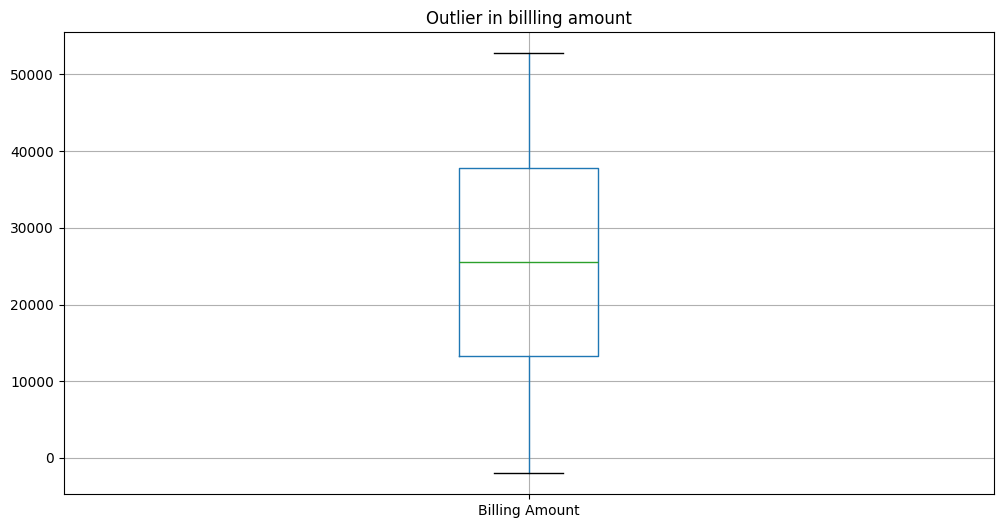

In [38]:
outlier = ['Billing Amount']
data[outlier].boxplot(figsize=(12,6))
plt.title("Outlier in billling amount")
plt.show()

In [26]:
## Before — confirm the problem
print('Negative billing rows:', (data['Billing Amount'] < 0).sum())
print('Minimum billing value:', data['Billing Amount'].min())

# Look at those rows
print(data[data['Billing Amount'] < 0][['Medical Condition', 'Admission Type', 
                                             'Billing Amount']].head(10))

# Fix — remove negative billing rows
data_clean = data[data['Billing Amount'] >= 0].copy()

Negative billing rows: 106
Minimum billing value: -2008.4921398591305
     Medical Condition Admission Type  Billing Amount
132             Cancer         Urgent     -502.507813
799             Asthma       Elective    -1018.245371
1018      Hypertension       Elective     -306.364925
1421            Asthma      Emergency     -109.097122
2103          Diabetes         Urgent     -576.727907
2696          Diabetes       Elective     -135.986000
2855      Hypertension       Elective     -370.983674
3772           Obesity       Elective    -1310.272895
5445         Arthritis       Elective     -692.408820
5708          Diabetes       Elective     -353.865186


In [29]:
# Remove all the negative Billing amount 

print("Row removed:",len(data)-len(data_clean))

Row removed: 106


In [31]:
print("row check after removing negative:",len(data))

row check after removing negative: 54966


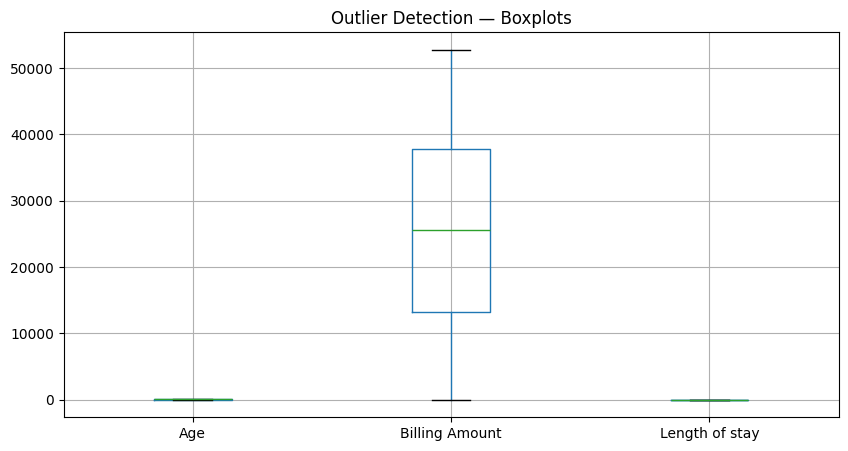

In [41]:
# Boxplots (simplified)
cols = ['Age', 'Billing Amount', 'Length of stay']

data_clean[cols].boxplot(figsize=(10, 5))
plt.title('Outlier Detection — Boxplots')
plt.savefig("../figures/outlier detection")
plt.show()

In [ ]:
s